# Bài tập: Huấn luyện cây quyết định và vẽ đồ thị cây  
## Chủ đề: Chẩn đoán bệnh tiểu đường

Notebook này hướng dẫn đầy đủ các bước để xây dựng mô hình **Decision Tree Classifier** cho bài toán dự đoán bệnh tiểu đường.

Mục tiêu chính:

- Đọc và kiểm tra dữ liệu `diabetes.csv`
- Chia dữ liệu thành tập train/test
- Huấn luyện mô hình Decision Tree
- Đánh giá mô hình bằng Accuracy, Confusion Matrix, Classification Report
- Vẽ cây quyết định để hiểu cách model đưa ra dự đoán

Dataset thường dùng: **Pima Indians Diabetes Dataset**.

## 1. Nhắc lại lý thuyết: Decision Tree là gì?

**Decision Tree** là thuật toán học máy dùng cấu trúc giống một cái cây để đưa ra quyết định.

Trong bài này, cây quyết định sẽ học từ dữ liệu bệnh nhân để phân loại:

- `Outcome = 0`: Không bị tiểu đường
- `Outcome = 1`: Có khả năng bị tiểu đường

Cây sẽ chia dữ liệu dựa trên các điều kiện như:

```text
Glucose <= 127.5
BMI <= 30.1
Age <= 28.5
```

Nếu điều kiện đúng thì đi sang nhánh trái, nếu sai thì đi sang nhánh phải.

## 2. Các cột dữ liệu trong bài toán

Dataset thường có các biến sau:

| Cột | Ý nghĩa |
|---|---|
| Pregnancies | Số lần mang thai |
| Glucose | Chỉ số glucose trong máu |
| BloodPressure | Huyết áp |
| SkinThickness | Độ dày da |
| Insulin | Chỉ số insulin |
| BMI | Chỉ số khối cơ thể |
| DiabetesPedigreeFunction | Chỉ số di truyền liên quan đến tiểu đường |
| Age | Tuổi |
| Outcome | Kết quả: 0 = không bệnh, 1 = có bệnh |

## 3. Import thư viện

Ta cần các thư viện chính:

- `pandas`: đọc và xử lý dữ liệu dạng bảng
- `matplotlib`: vẽ biểu đồ
- `train_test_split`: chia dữ liệu thành train/test
- `DecisionTreeClassifier`: mô hình cây quyết định
- `plot_tree`: vẽ cây quyết định
- `accuracy_score`, `classification_report`, `confusion_matrix`: đánh giá mô hình

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 4. Đọc dữ liệu

File dữ liệu nên đặt cùng thư mục với notebook và có tên:

```text
diabetes.csv
```

Nếu file của bạn có tên khác, hãy sửa lại dòng `pd.read_csv()`.

In [5]:
# Đổi tên file này theo đúng file CSV bạn đã tải về
file_path = "../../data/diabetes/diabetes.csv"


# Thử đọc dataset có header trước
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Không tìm thấy file: {file_path}")
    print("Hãy đặt file CSV cùng thư mục với notebook hoặc sửa lại file_path.")

# Xem 5 dòng đầu
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 5. Kiểm tra tổng quan dữ liệu

Ở bước này, ta kiểm tra:

- Dữ liệu có bao nhiêu dòng, bao nhiêu cột
- Kiểu dữ liệu của từng cột
- Có giá trị thiếu hay không
- Phân phối của biến mục tiêu `Outcome`

In [6]:
# Kiểm tra thông tin tổng quan
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [7]:
# Thống kê mô tả dữ liệu số
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [8]:
# Kiểm tra số lượng từng class trong Outcome
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


### Giải thích

Nếu `Outcome` có dạng:

```text
0    nhiều mẫu
1    ít mẫu hơn
```

thì nghĩa là số người không bị tiểu đường nhiều hơn số người bị tiểu đường. Đây là hiện tượng khá phổ biến trong dữ liệu y tế.

## 6. Tách biến đầu vào X và biến mục tiêu y

Trong Machine Learning:

- `X`: các biến đầu vào dùng để dự đoán
- `y`: kết quả cần dự đoán

Ở đây:

```text
X = tất cả cột trừ Outcome
y = Outcome
```

In [9]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (768, 8)
Kích thước y: (768,)


## 7. Chia dữ liệu thành train/test

Ta chia dữ liệu thành:

- `X_train`, `y_train`: dùng để huấn luyện model
- `X_test`, `y_test`: dùng để kiểm tra model

Ở đây dùng tỷ lệ:

```text
80% train
20% test
```

Tham số `stratify=y` giúp tỷ lệ class 0 và class 1 trong train/test gần giống dữ liệu ban đầu.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


## 8. Huấn luyện mô hình Decision Tree

Ta tạo model Decision Tree với các tham số:

```text
criterion = "gini"
max_depth = 4
random_state = 42
```

Ý nghĩa:

- `criterion="gini"`: dùng chỉ số Gini Impurity để chọn cách chia nhánh
- `max_depth=4`: giới hạn độ sâu của cây, tránh cây quá phức tạp và overfitting
- `random_state=42`: giúp kết quả ổn định khi chạy lại

In [11]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Huấn luyện mô hình hoàn tất!")

Huấn luyện mô hình hoàn tất!


## 9. Dự đoán trên tập test

Sau khi model đã học từ tập train, ta dùng nó để dự đoán kết quả cho tập test.

In [12]:
y_pred = model.predict(X_test)

print("Một số kết quả dự đoán đầu tiên:")
print(y_pred[:20])

Một số kết quả dự đoán đầu tiên:
[1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0]


## 10. Đánh giá mô hình

Ta dùng ba nhóm chỉ số chính:

### Accuracy

Accuracy cho biết model dự đoán đúng bao nhiêu phần trăm trên tập test.

Công thức:

$$
Accuracy = \frac{\text{Số dự đoán đúng}}{\text{Tổng số dự đoán}}
$$

### Confusion Matrix

Confusion Matrix cho biết model nhầm lẫn giữa class 0 và class 1 như thế nào.

### Classification Report

Gồm các chỉ số:

- `precision`: trong các ca model dự đoán là có bệnh, bao nhiêu ca thật sự có bệnh
- `recall`: trong các ca thật sự có bệnh, model phát hiện được bao nhiêu ca
- `f1-score`: trung bình điều hòa giữa precision và recall

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7987012987012987


In [14]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[88 12]
 [19 35]]


In [15]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       100
           1       0.74      0.65      0.69        54

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.80      0.80      0.80       154



## 11. Vẽ cây quyết định

Đây là phần quan trọng nhất của bài tập.

Cây quyết định giúp ta nhìn được model đang chia dữ liệu theo điều kiện nào.

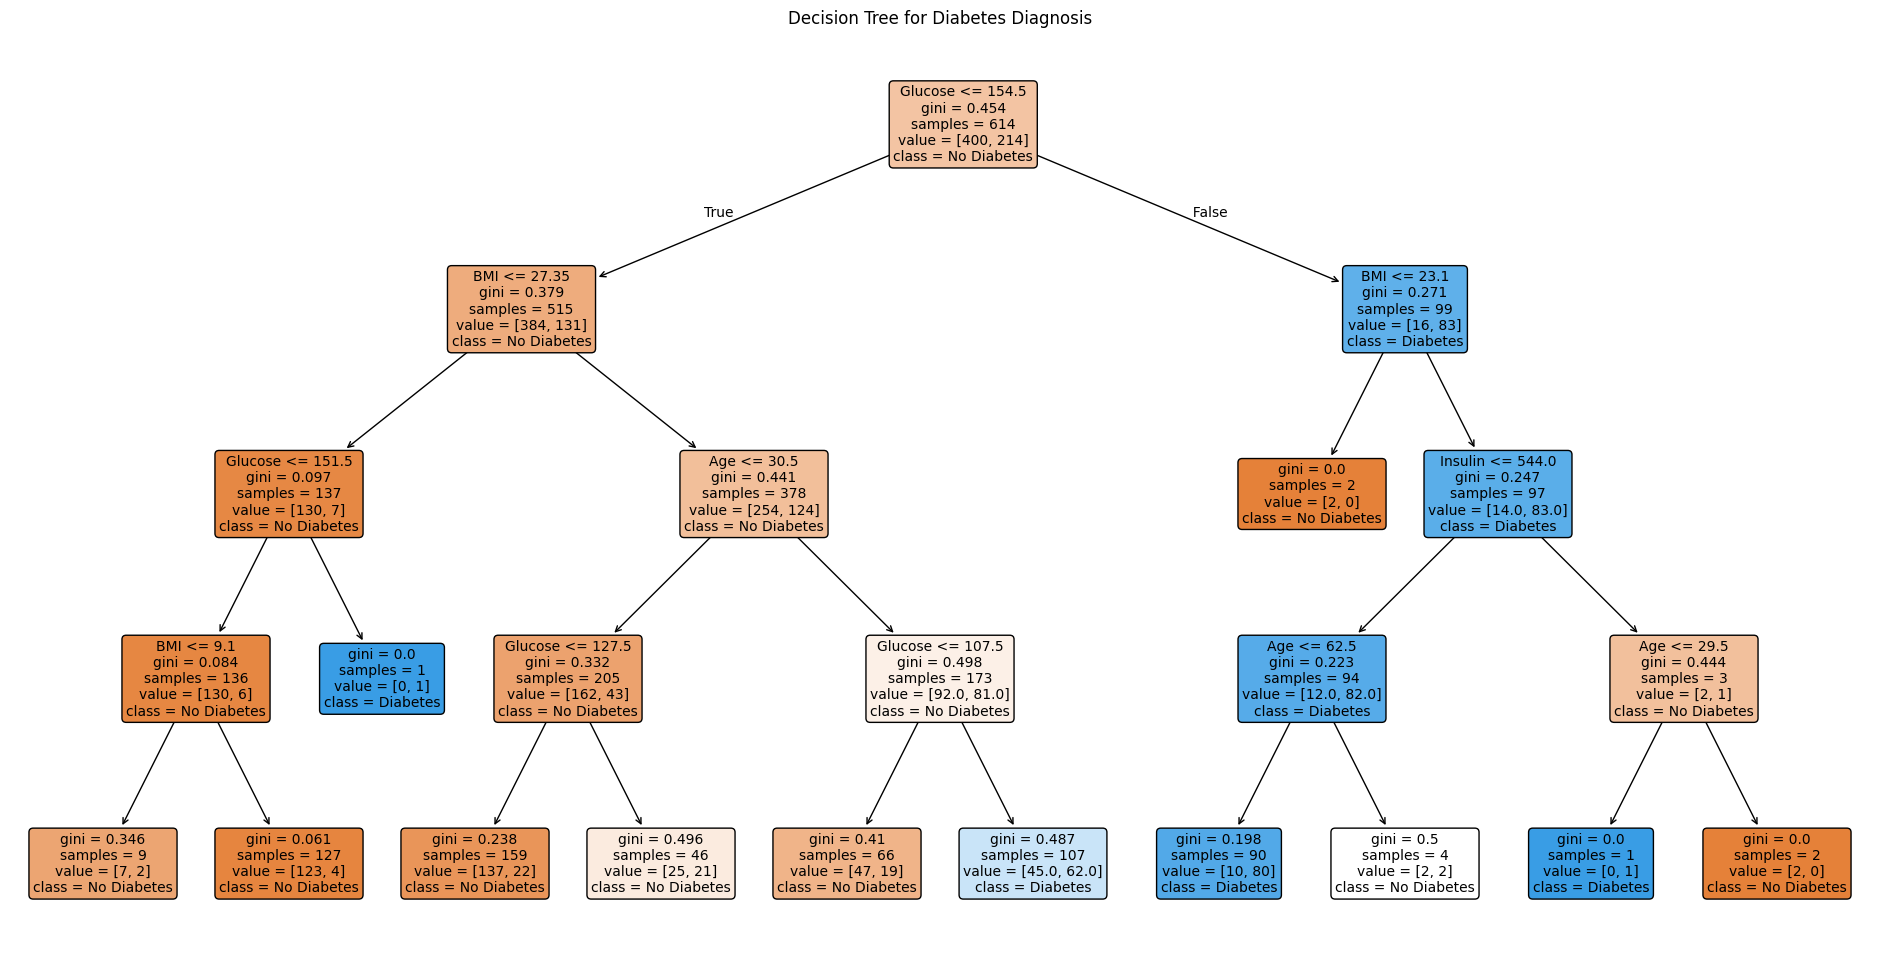

In [16]:
plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Diabetes Diagnosis")
plt.show()

## 12. Cách đọc cây quyết định

Trong mỗi node của cây, ta thường thấy các thông tin như:

```text
Glucose <= 127.5
gini = 0.45
samples = 614
value = [400, 214]
class = No Diabetes
```

Ý nghĩa:

- `Glucose <= 127.5`: điều kiện chia nhánh
- `gini`: độ hỗn loạn của dữ liệu tại node đó
- `samples`: số lượng mẫu dữ liệu tại node đó
- `value = [400, 214]`: có 400 mẫu class 0 và 214 mẫu class 1
- `class = No Diabetes`: class được model chọn làm dự đoán tại node đó

Quy tắc đọc:

```text
Nếu điều kiện đúng → đi nhánh trái
Nếu điều kiện sai → đi nhánh phải
```

## 13. Thử dự đoán một bệnh nhân mới

Ta có thể tạo một bệnh nhân giả định với các chỉ số sức khỏe rồi dùng model để dự đoán.

Lưu ý: thứ tự các giá trị phải đúng theo thứ tự cột trong `X.columns`.

In [17]:
# Xem thứ tự các cột đầu vào
print(X.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


In [19]:
# Ví dụ một bệnh nhân mới
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [140],
    "BloodPressure": [140],
    "SkinThickness": [35],
    "Insulin": [0],
    "BMI": [33.6],
    "DiabetesPedigreeFunction": [0.627],
    "Age": [45]
})

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Dự đoán: Có khả năng bị tiểu đường")
else:
    print("Dự đoán: Không bị tiểu đường")

Dự đoán: Có khả năng bị tiểu đường


## 14. Xem độ quan trọng của các biến

Decision Tree có thể cho biết biến nào ảnh hưởng nhiều đến việc phân loại.

Ví dụ trong bài toán tiểu đường, các biến như `Glucose`, `BMI`, `Age` thường có vai trò quan trọng.

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,Glucose,0.670911
5,BMI,0.174665
7,Age,0.138818
4,Insulin,0.015606
3,SkinThickness,0.000000
2,BloodPressure,0.000000
0,Pregnancies,0.000000
6,DiabetesPedigreeFunction,0.000000


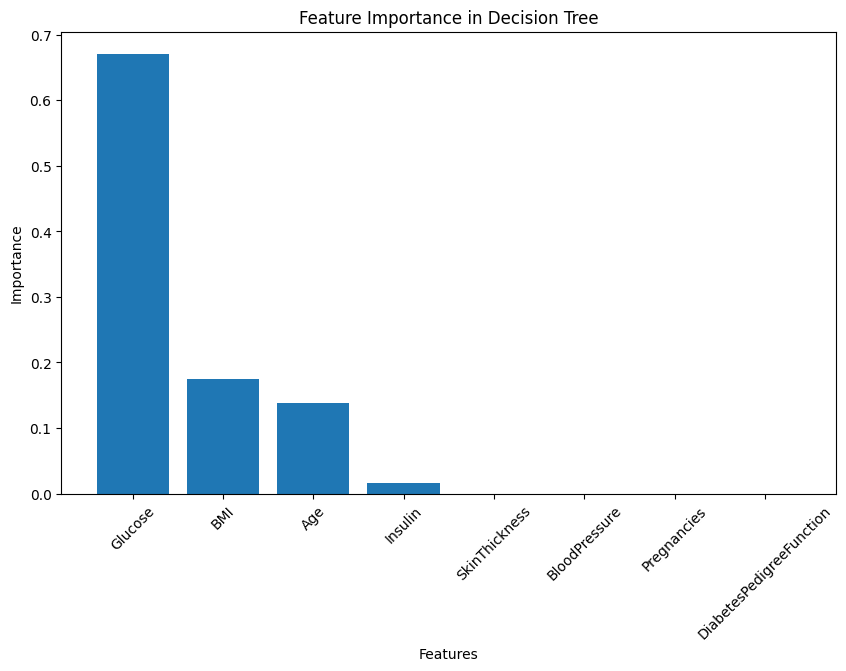

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Decision Tree")
plt.show()

## 15. Kết luận bài tập

Trong bài tập này, ta đã xây dựng mô hình **Decision Tree Classifier** để dự đoán nguy cơ mắc bệnh tiểu đường dựa trên các thông tin sức khỏe của bệnh nhân.

Các bước đã thực hiện:

1. Đọc dữ liệu `diabetes.csv`
2. Kiểm tra tổng quan dữ liệu
3. Tách biến đầu vào `X` và biến mục tiêu `y`
4. Chia dữ liệu thành tập train/test
5. Huấn luyện mô hình Decision Tree
6. Đánh giá mô hình bằng Accuracy, Confusion Matrix và Classification Report
7. Vẽ cây quyết định để quan sát cách model chia nhánh
8. Kiểm tra độ quan trọng của các biến

Kết luận chính:

Decision Tree là mô hình dễ hiểu, dễ giải thích và trực quan. Trong bài toán chẩn đoán tiểu đường, model có thể học các quy luật từ dữ liệu như chỉ số `Glucose`, `BMI`, `Age` để phân loại bệnh nhân. Tuy nhiên, nếu cây quá sâu, model có thể bị **overfitting**, vì vậy cần giới hạn `max_depth` hoặc dùng các kỹ thuật kiểm soát khác.